<a href="https://colab.research.google.com/github/Vaneelins/Vaneelins/blob/main/Climatologia_de_Santa_Catarina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install netCDF4 xarray matplotlib cartopy numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.2 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from google.colab import drive #para logar no drive

# Carregar o arquivo NetCDF (substitua pelo caminho do seu arquivo)
# Montar o Google Drive
drive.mount('/content/drive')

# Carregar o arquivo NetCDF
caminho_arquivo = '/content/drive/MyDrive/TCC2/Arquivotcc/1991-2020-SulAmerica.nc'
ds = xr.open_dataset(caminho_arquivo)
# Visualizar as variáveis disponíveis
print(ds)

Mounted at /content/drive
<xarray.Dataset> Size: 93MB
Dimensions:     (valid_time: 360, latitude: 269, longitude: 241)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * latitude    (latitude) float64 2kB 12.0 11.75 11.5 ... -54.5 -54.75 -55.0
  * longitude   (longitude) float64 2kB -80.0 -79.75 -79.5 ... -20.25 -20.0
    expver      (valid_time) <U4 6kB ...
Data variables:
    tcslw       (valid_time, latitude, longitude) float32 93MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts


In [ ]:
# 1. Definir os limites geográficos de Santa Catarina (aproximados)
lat_min, lat_max = -29.9, -24.9
lon_min, lon_max = -54.9, -48.0

# 2. Selecionar apenas os dados para Santa Catarina
dados_sc= ds.sel(
    latitude=slice(lat_max, lat_min),  # Note a ordem invertida para latitude
    longitude=slice(lon_min, lon_max)
)

# 3. Média mensal climatológica para SC (agrupando por mês)
climatology_sc = dados_sc['tcslw'].groupby('valid_time.month').mean(dim='valid_time')

# 4. Anomalias em relação à climatologia para SC
anomalies_sc = dados_sc['tcslw'].groupby('valid_time.month') - climatology_sc

# 5. Média espacial sobre Santa Catarina para análise temporal
ts_mean_sc = dados_sc['tcslw'].mean(dim=['latitude', 'longitude'])

# 6. Converter para DataFrame do Pandas
df_sc = ts_mean_sc.to_dataframe(name='tcslw').reset_index()

# 7. Verificar e limpar os dados
print(df_sc.dtypes)
print(df_sc.head())

# 8. Garantir que a coluna 'tcslw' é numérica
df_sc['tcslw'] = pd.to_numeric(df_sc['tcslw'], errors='coerce')

# 9. Remover valores NaN
df_sc = df_sc.dropna(subset=['tcslw'])

# 10. Calcular média anual para Santa Catarina
df_sc['year'] = df_sc['valid_time'].dt.year
annual_mean_sc = df_sc.groupby('year')['tcslw'].mean()

# Verificar o resultado
print(annual_mean_sc.head())

valid_time    datetime64[ns]
number                 int64
expver                object
tcslw                float32
dtype: object
           valid_time  number expver     tcslw
0 1991-01-01 06:00:00       0   0001  0.017964
1 1991-02-01 06:00:00       0   0001  0.014663
2 1991-03-01 06:00:00       0   0001  0.014207
3 1991-04-01 06:00:00       0   0001  0.015275
4 1991-05-01 06:00:00       0   0001  0.011258
year
1991    0.017686
1992    0.020863
1993    0.021173
1994    0.019045
1995    0.021974
Name: tcslw, dtype: float32


Dados utilizados para a tendência:
Anos: [1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004
 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020]
Valores: [0.01768623 0.0208632  0.0211726  0.0190452  0.0219738  0.02091918
 0.02037918 0.02207731 0.01955911 0.01970938 0.0202525  0.01910456
 0.01659513 0.01977389 0.01980721 0.0167179  0.02116992 0.02206335
 0.02109667 0.02401478 0.02357851 0.01930818 0.02017172 0.01935141
 0.02196372 0.01957131 0.01901027 0.01960887 0.01867194 0.01851404]

Estatísticas da regressão:
Inclinação: -0.00001
Intercepto: 0.03626
R²: 0.00168
Valor-p: 0.82964


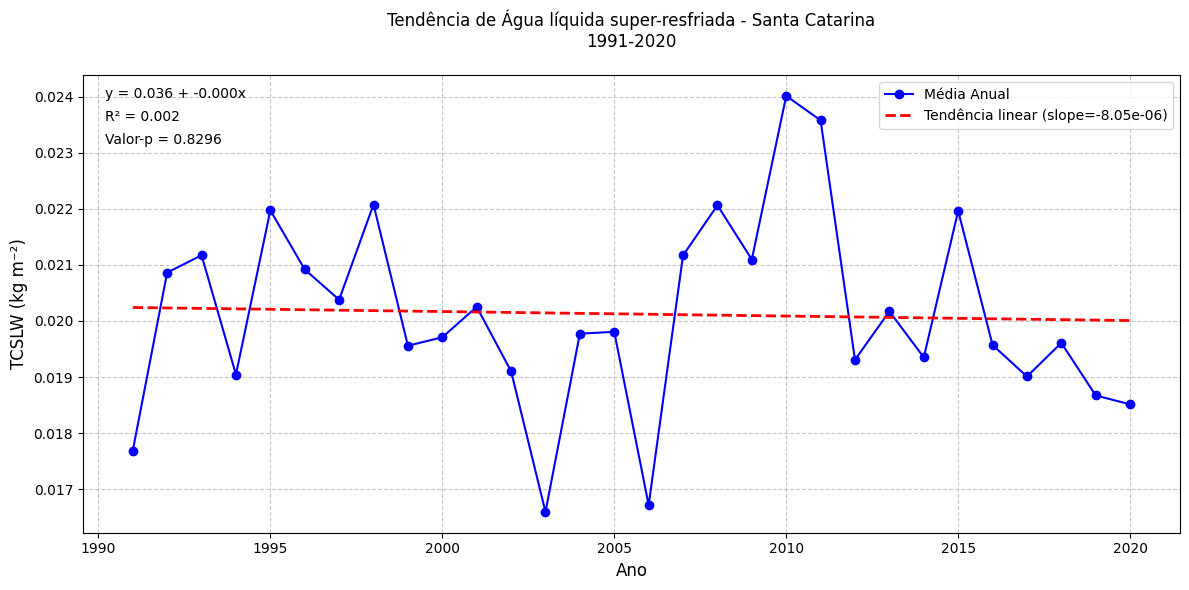

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Verificação dos dados
print("Dados utilizados para a tendência:")
print(f"Anos: {annual_mean_sc.index.values}")
print(f"Valores: {annual_mean_sc.values}")

# Garantir que os dados são numéricos
years = annual_mean_sc.index.astype(float)  # Converter anos para float
values = annual_mean_sc.astype(float)       # Garantir que valores são float

# Cálculo da regressão linear com verificação
slope, intercept, r_value, p_value, std_err = linregress(years, values)
print(f"\nEstatísticas da regressão:")
print(f"Inclinação: {slope:.5f}")
print(f"Intercepto: {intercept:.5f}")
print(f"R²: {r_value**2:.5f}")
print(f"Valor-p: {p_value:.5f}")

# Criar figura
plt.figure(figsize=(12, 6))

# Plot dos dados originais
plt.plot(years, values, 'bo-', label='Média Anual')

# Plot da linha de tendência
trend_line = intercept + slope * years
plt.plot(years, trend_line, 'r--', linewidth=2, label=f'Tendência linear (slope={slope:.2e})')

# Ajustes do gráfico
plt.title('Tendência de Água líquida super-resfriada - Santa Catarina\n1991-2020', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('TCSLW (kg m⁻²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)

# Adicionar informações da regressão
plt.text(0.02, 0.95, f'y = {intercept:.3f} + {slope:.3f}x', transform=plt.gca().transAxes)
plt.text(0.02, 0.90, f'R² = {r_value**2:.3f}', transform=plt.gca().transAxes)
plt.text(0.02, 0.85, f'Valor-p = {p_value:.4f}', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

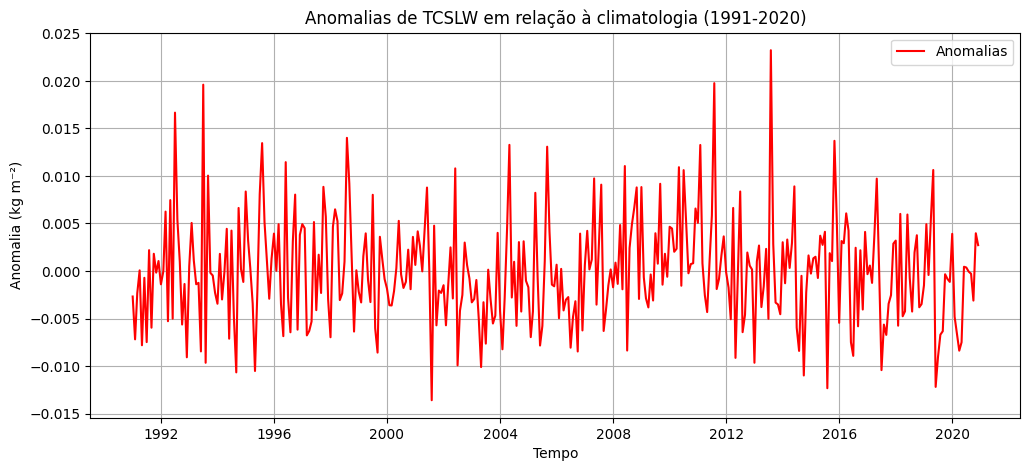

In [ ]:
plt.figure(figsize=(12, 5))
anomalies_sc.mean(dim=['latitude', 'longitude']).plot(color='red', label='Anomalias')
plt.title('Anomalias de TCSLW em relação à climatologia (1991-2020)')
plt.xlabel('Tempo')
plt.ylabel('Anomalia (kg m⁻²)')
plt.grid(True)
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


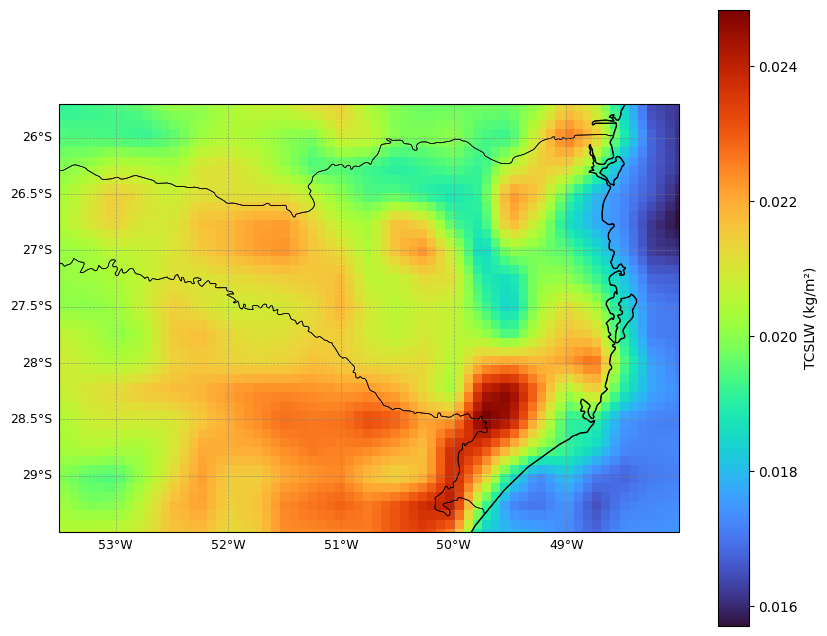

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


# Média da climatologia mensal
mean_tcs = climatology_sc.mean(dim='month')

# Máscara para valores zero
masked = mean_tcs.where(mean_tcs != 0)


# Interpola os dados para uma grade mais densa (suavização)
masked_interp = masked.interp(
    longitude=np.linspace(float(masked.longitude.min()), float(masked.longitude.max()), masked.sizes['longitude'] * 3),
    latitude=np.linspace(float(masked.latitude.min()), float(masked.latitude.max()), masked.sizes['latitude'] * 3)
)

# Cria a figura
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plota os dados mascarados
#plot = masked.plot(
    #ax=ax,
    #cmap='turbo',
    #add_colorbar=True,
    #cbar_kwargs={'label': 'TCSLW (kg/m²)'}
#)

# Adiciona feições do mapa
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)

# Recorte para Santa Catarina
ax.set_extent([-53.5, -48.0, -29.5, -25.7], crs=ccrs.PlateCarree())

# Adiciona linhas de latitude e longitude com rótulos
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}
gl.xformatter = ccrs.cartopy.mpl.gridliner.LONGITUDE_FORMATTER
gl.yformatter = ccrs.cartopy.mpl.gridliner.LATITUDE_FORMATTER

# Título do gráfico
ax.set_title('Média Climatológica de TCSLW (1991–2020)', fontsize=14)

plot = masked_interp.plot(
    ax=ax,
    cmap='turbo',
    add_colorbar=True,
    cbar_kwargs={'label': 'TCSLW (kg/m²)'},
    transform=ccrs.PlateCarree()
)

<xarray.Dataset> Size: 815kB
Dimensions:     (valid_time: 360, latitude: 20, longitude: 28)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * latitude    (latitude) float64 160B -25.0 -25.25 -25.5 ... -29.5 -29.75
  * longitude   (longitude) float64 224B -54.75 -54.5 -54.25 ... -48.25 -48.0
    expver      (valid_time) <U4 6kB ...
Data variables:
    tcslw       (valid_time, latitude, longitude) float32 806kB 0.01597 ... 0...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
Shape após filtro: (360, 20, 28)
Média tcslw SC: 0.0201244056224823
Dimensões do dataset (Santa Catarina):
FrozenMappingWarningOnValuesAccess({'valid_time': 360, 'latitude': 20, 'longitude': 28})

Estatísticas de tcslw e

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


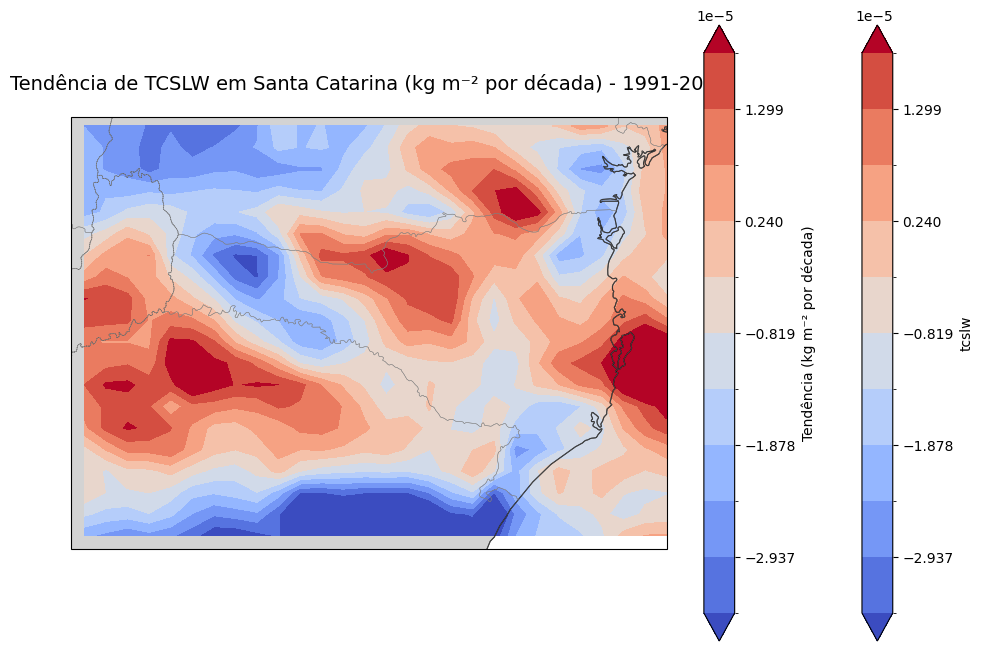

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress

#lat_min, lat_max = -29.5, -25.9
#lon_min, lon_max = -54.0, -48.0

# Latitude decrescente, longitude crescente:
#dados_sc = ds.sel(
    #latitude=slice(lat_max, lat_min),
    #longitude=slice(lon_min, lon_max)  )

print(dados_sc)
print(f"Shape após filtro: {dados_sc['tcslw'].shape}")
print(f"Média tcslw SC: {dados_sc['tcslw'].mean().values}")

# 3. Verificar a estrutura dos dados filtrados
print("Dimensões do dataset (Santa Catarina):")
print(dados_sc.dims)
print("\nEstatísticas de tcslw em Santa Catarina:")
print(f"Média: {dados_sc['tcslw'].mean().values:.4f}")
print(f"Desvio padrão: {dados_sc['tcslw'].std().values:.4f}")

# 4. Função para cálculo de tendência (igual ao original)
def calculate_trend(ts):
    x = np.arange(len(ts))
    if np.isnan(ts).all() or len(ts[~np.isnan(ts)]) < 2:
        return np.nan
    slope, _, _, _, _ = linregress(x[~np.isnan(ts)], ts[~np.isnan(ts)])
    return slope * 10  # Tendência por década

# 5. Calcular tendências para Santa Catarina
trend_sc = xr.apply_ufunc(
    calculate_trend,
    dados_sc['tcslw'],
    input_core_dims=[['valid_time']],
    output_dtypes=[float],
    vectorize=True,
    dask='parallelized'
)

# 6. Configurações do plot
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Definir níveis de contorno baseados nos percentis (ajustados para Santa Catarina)
trend_values = trend_sc.values
vmin = np.nanpercentile(trend_values, 5)
vmax = np.nanpercentile(trend_values, 95)
levels = np.linspace(vmin, vmax, 11)

# Plotar tendências
plot = trend_sc.plot.contourf(
    ax=ax,
    cmap='coolwarm',
    levels=levels,
    add_colorbar=True,
    extend='both',
    transform=ccrs.PlateCarree()
)

# Adicionar características geográficas
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.3, edgecolor='gray')  # Estados brasileiros
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Título e rótulos
plt.title('Tendência de TCSLW em Santa Catarina (kg m⁻² por década) - 1991-2020', pad=20, fontsize=14)
plt.colorbar(plot, label='Tendência (kg m⁻² por década)', extend='both')

# Ajustar a view para Santa Catarina
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

plt.show()

In [ ]:
print(masked.dims)
print(masked.coords)

('latitude', 'longitude')
Coordinates:
  * latitude   (latitude) float64 160B -25.0 -25.25 -25.5 ... -29.5 -29.75
  * longitude  (longitude) float64 224B -54.75 -54.5 -54.25 ... -48.25 -48.0


In [ ]:
print("Latitude valores mínimos e máximos:", ds.latitude.min().values, ds.latitude.max().values)
print("Longitude valores mínimos e máximos:", ds.longitude.min().values, ds.longitude.max().values)

print("Latitude array exemplo:", ds.latitude.values[:10])
print("Longitude array exemplo:", ds.longitude.values[:10])

Latitude valores mínimos e máximos: -55.0 12.0
Longitude valores mínimos e máximos: -80.0 -20.0
Latitude array exemplo: [12.   11.75 11.5  11.25 11.   10.75 10.5  10.25 10.    9.75]
Longitude array exemplo: [-80.   -79.75 -79.5  -79.25 -79.   -78.75 -78.5  -78.25 -78.   -77.75]


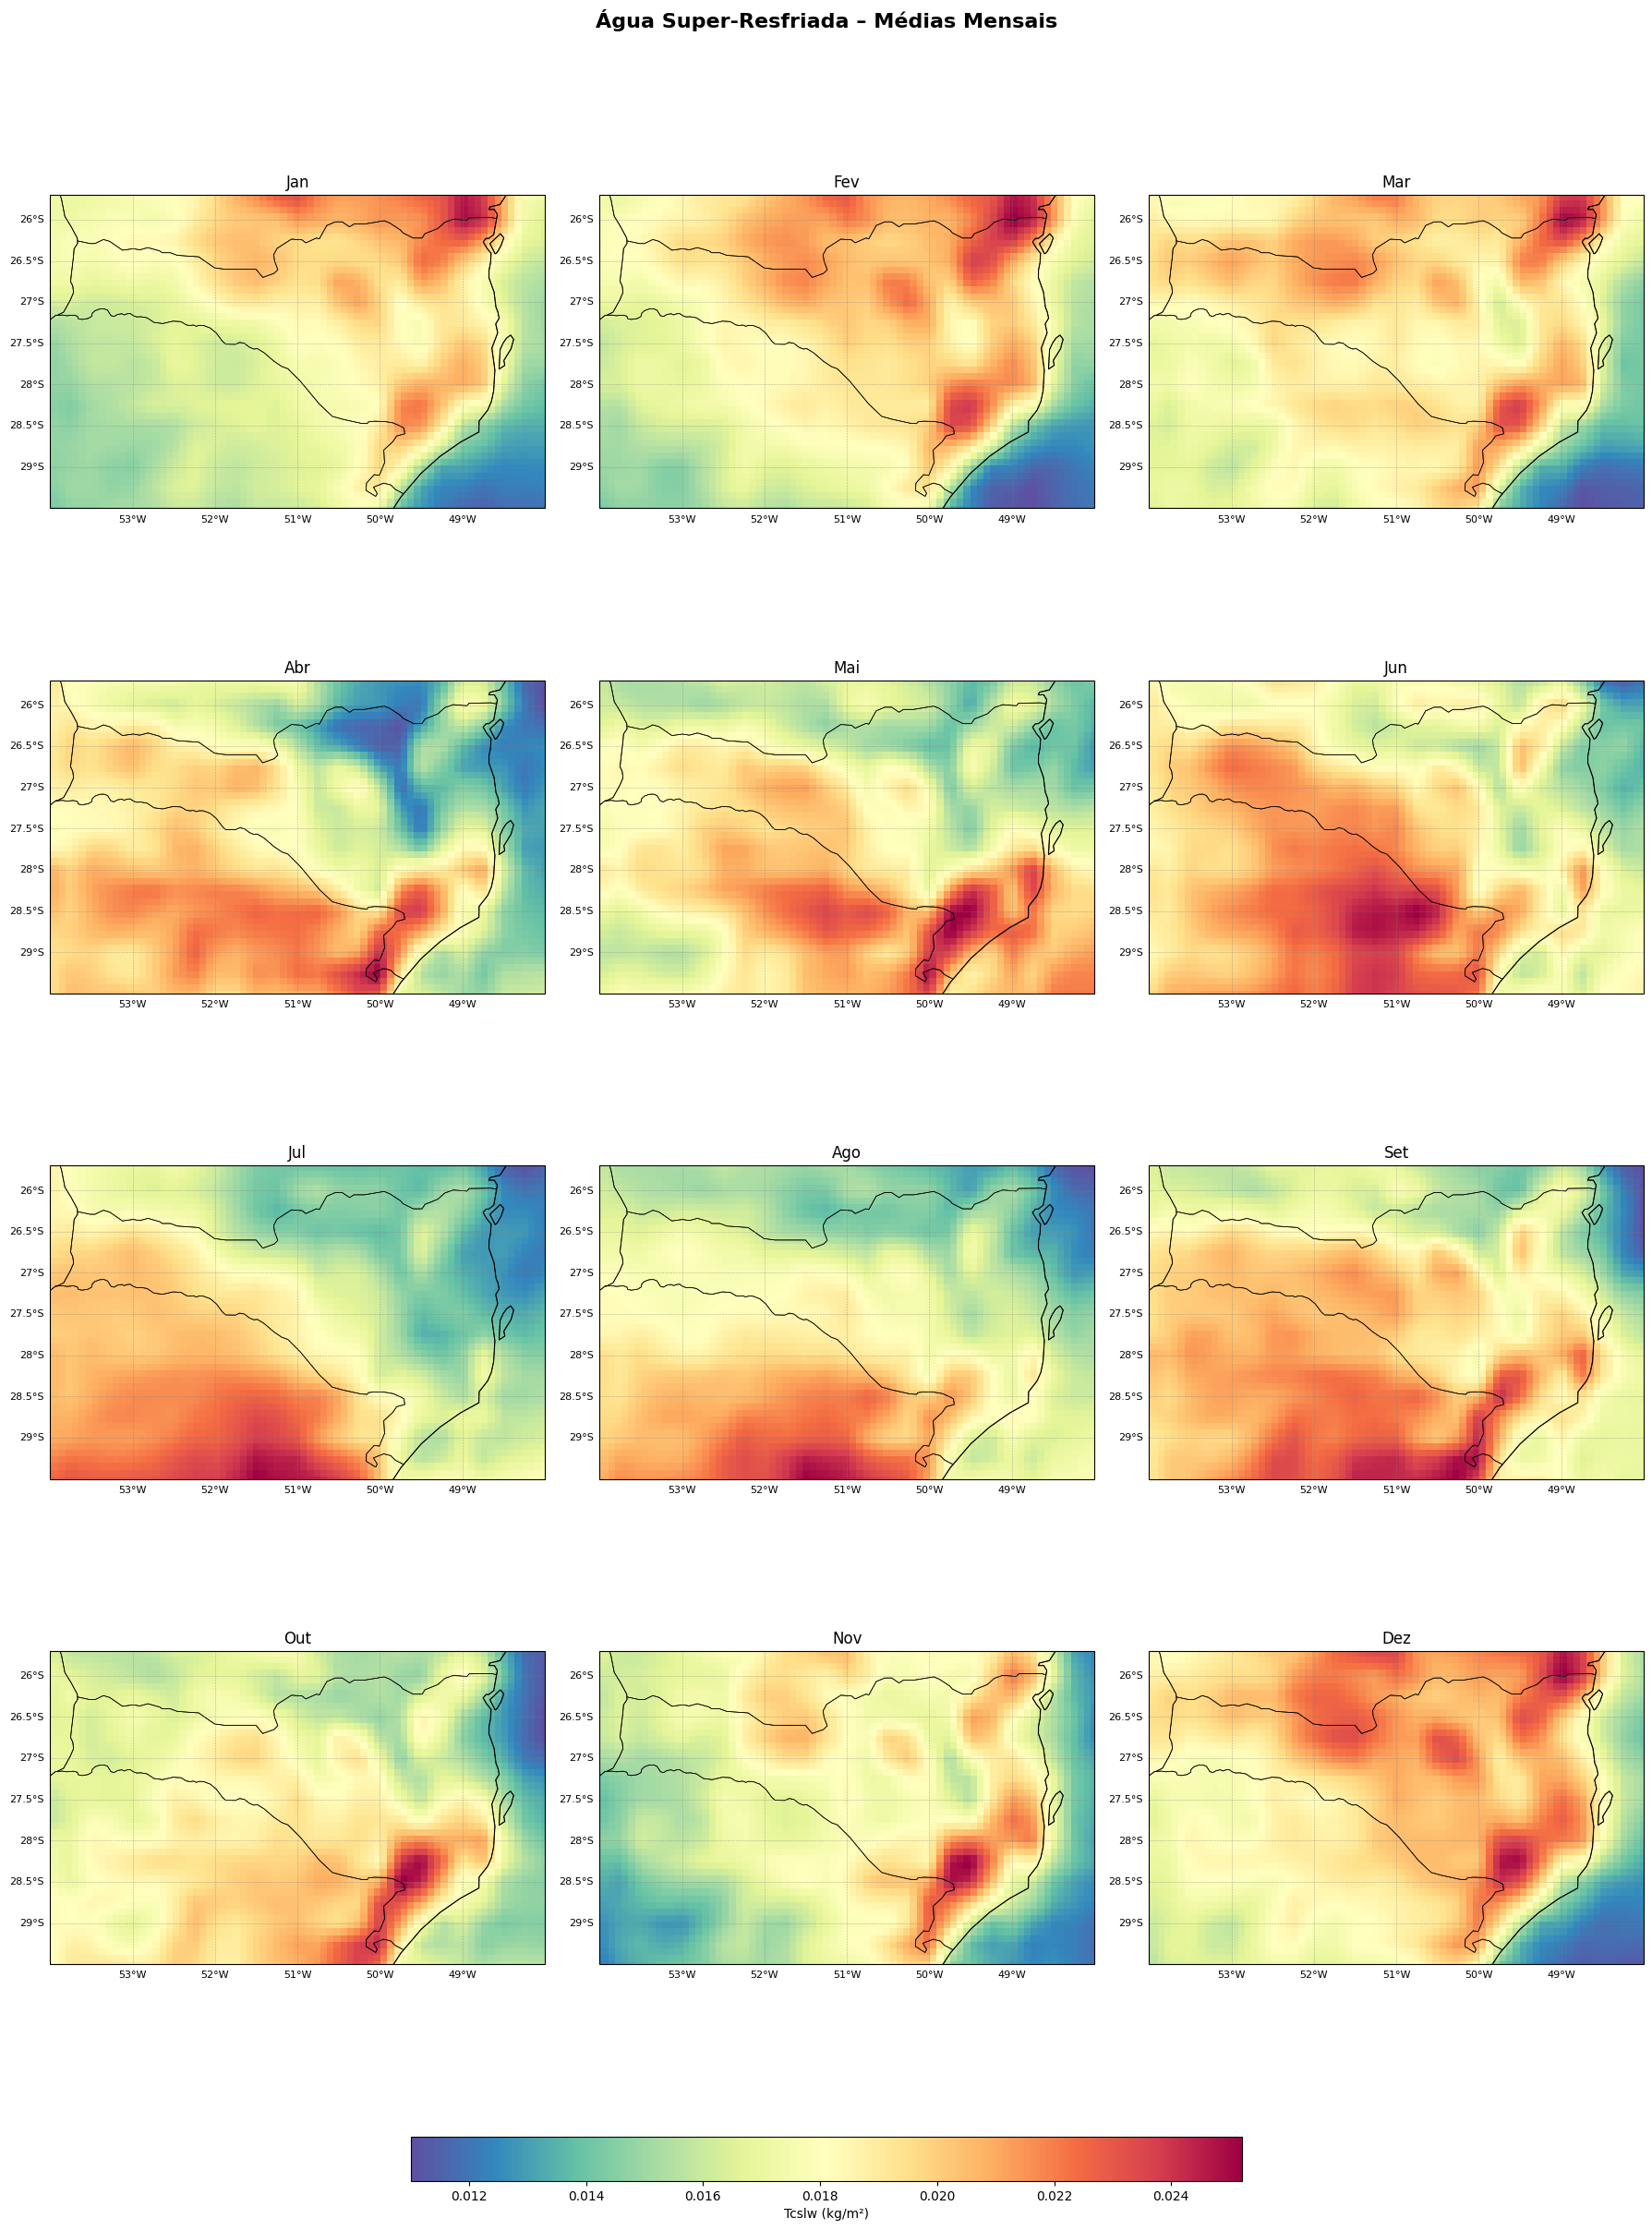

In [ ]:
#Criação do Mosaico

# Calcular médias mensais
media_mensal = dados_sc['tcslw'].groupby('valid_time.month').mean(dim='valid_time')

# Obter os nomes corretos das coordenadas
lat = media_mensal.latitude
lon = media_mensal.longitude

# Interpola os dados para uma grade mais densa (suavização)
media_mensal_interp = media_mensal.interp(
    longitude=np.linspace(float(lon.min()), float(lon.max()), lon.size * 3),
    latitude=np.linspace(float(lat.min()), float(lat.max()), lat.size * 3)
)

# Plotar 12 mapas mensais
fig, axs = plt.subplots(4, 3, figsize=(18, 24), subplot_kw={'projection': ccrs.PlateCarree()})
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
fig.subplots_adjust(top=0.92)  # Move o conteúdo um pouco para baixo
fig.suptitle('Água Super-Resfriada – Médias Mensais', fontsize=16, fontweight='bold', y=1)


for i, ax in enumerate(axs.flat):
    p = media_mensal_interp.sel(month=i+1).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='Spectral_r',
        add_colorbar=False
    )
    ax.set_title(meses[i], fontsize=12)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle='-', linewidth=0.6)
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)

    # Recorte para Santa Catarina
    ax.set_extent([-54, -48.0, -29.5, -25.7], crs=ccrs.PlateCarree())

    # Gridlines com labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# Criar barra de cores horizontal
import matplotlib.colorbar as cbar

#Usar a primeira camada para pegar os valores de cor
#im = axs[0, 0].pcolormesh(
    #dados_sc['tcslw'].longitude,
    #dados_sc['tcslw'].latitude,
    #media_mensal.sel(month=1),
    #cmap='Spectral_r',
    #transform=ccrs.PlateCarree()
#)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Deixa espaço embaixo para o colorbar

# Adicionar barra de cores horizontal fora dos subplots
cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
cb = plt.colorbar(p, cax=cbar_ax, orientation='horizontal')
cb.set_label('Tcslw (kg/m²)')


In [ ]:
#Para Climatologia Mensal - Biblioteca para eu fazer apenas as coordenadas de santa Catarina
!pip install geopandas shapely rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 53.2 MB/s eta 0:00:00


In [ ]:
#importando as bibliotecas
import geopandas as gpd
import xarray as xr
import rioxarray
from shapely.geometry import mapping
import os

In [ ]:
from google.colab import drive #para logar no drive
# Carregar o arquivo de Malhas (substitua pelo caminho do seu arquivo)
# Montar o Google Drive
drive.mount('/content/drive')

# Carregar o arquivo de Malhas
shapefile_path = '/content/drive/MyDrive/Malhas_UF/BR_UF_2024.shp'
estados = gpd.read_file(shapefile_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(estados.columns)

Index(['CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG',
       'AREA_KM2', 'geometry'],
      dtype='object')


In [ ]:

# Filtra Santa Catarina (ajuste se a coluna de nome for diferente)
sc = estados[estados['NM_UF'] == 'Santa Catarina']

# Garante que está no sistema de coordenadas certo (WGS84)
sc = sc.to_crs("EPSG:4326")

In [ ]:
# Garante que o dataset tem sistema de coordenadas definido
dados_sc.rio.write_crs("EPSG:4326", inplace=True)

# Faz o recorte usando o shapefile de SC
dados_sc_recortado = dados_sc.rio.clip(sc.geometry, sc.crs, drop=True, invert=False)

/tmp/ipython-input-55-892219329.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(valores_mensais, labels=meses, patch_artist=True,


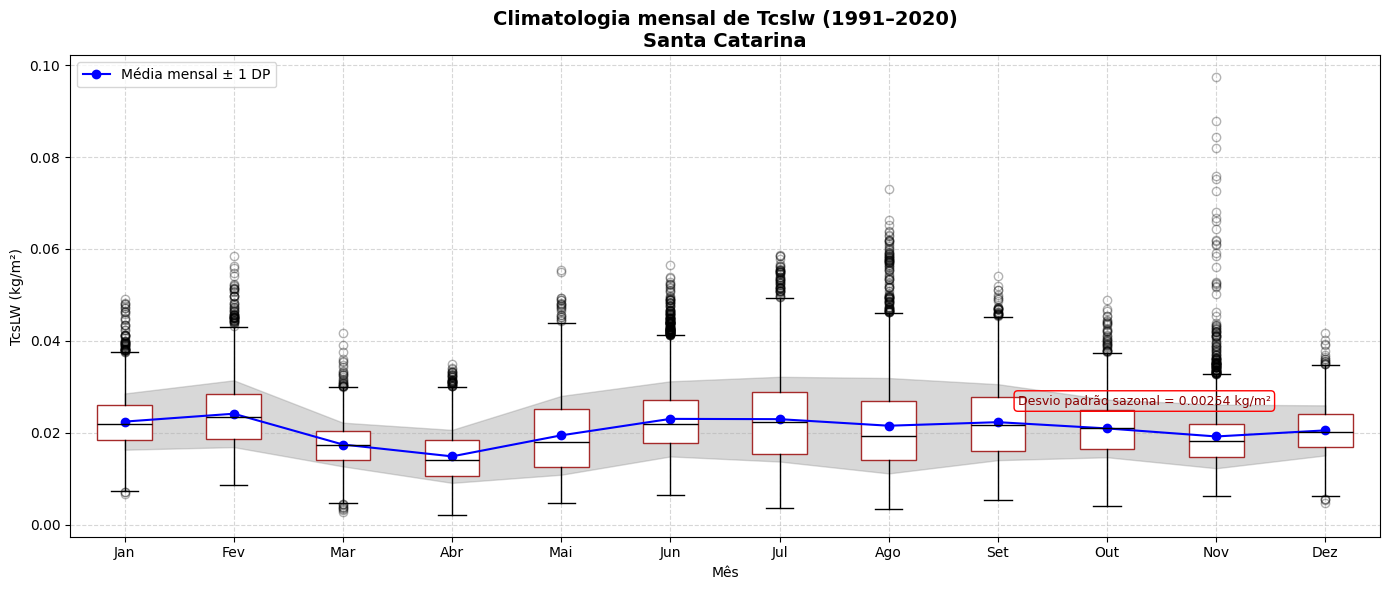

In [ ]:
# Agrupar os dados por mês
tcslw_mensal = dados_sc_recortado['tcslw'].groupby('valid_time.month')

# Extrair os valores mensais (vetores 1D, sem NaN)
valores_mensais = [tcslw_mensal.groups[m] for m in range(1, 13)]  # índices de tempo

valores_mensais = [
    dados_sc_recortado['tcslw'].isel(valid_time=tcslw_mensal.groups[m]).values.flatten()
    for m in range(1, 13)
]
valores_mensais = [v[~np.isnan(v)] for v in valores_mensais]

# Calcular média e desvio padrão
medias = [v.mean() for v in valores_mensais]
stds = [v.std() for v in valores_mensais]
dp_sazonal = np.std(medias)

meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(valores_mensais, labels=meses, patch_artist=True,
           boxprops=dict(facecolor='white', color='brown'),
           medianprops=dict(color='black'),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', color='gray', alpha=0.3))

ax.plot(range(1, 13), medias, color='blue', marker='o', label='Média mensal ± 1 DP')
ax.fill_between(range(1, 13),
                np.array(medias) - np.array(stds),
                np.array(medias) + np.array(stds),
                color='gray', alpha=0.3)

ax.set_title('Climatologia mensal de Tcslw (1991–2020)\nSanta Catarina', fontsize=14, weight='bold')
ax.set_ylabel('TcsLW (kg/m²)')
ax.set_xlabel('Mês')
ax.grid(True, linestyle='--', alpha=0.5)

ax.text(11.5, max(medias) + 0.002,
        f'Desvio padrão sazonal = {dp_sazonal:.5f} kg/m²',
        fontsize=9, color='darkred',
        horizontalalignment='right',
        bbox=dict(facecolor='none', edgecolor='red', boxstyle='round,pad=0.3'))

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipython-input-56-3284156072.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(valores_mensais,


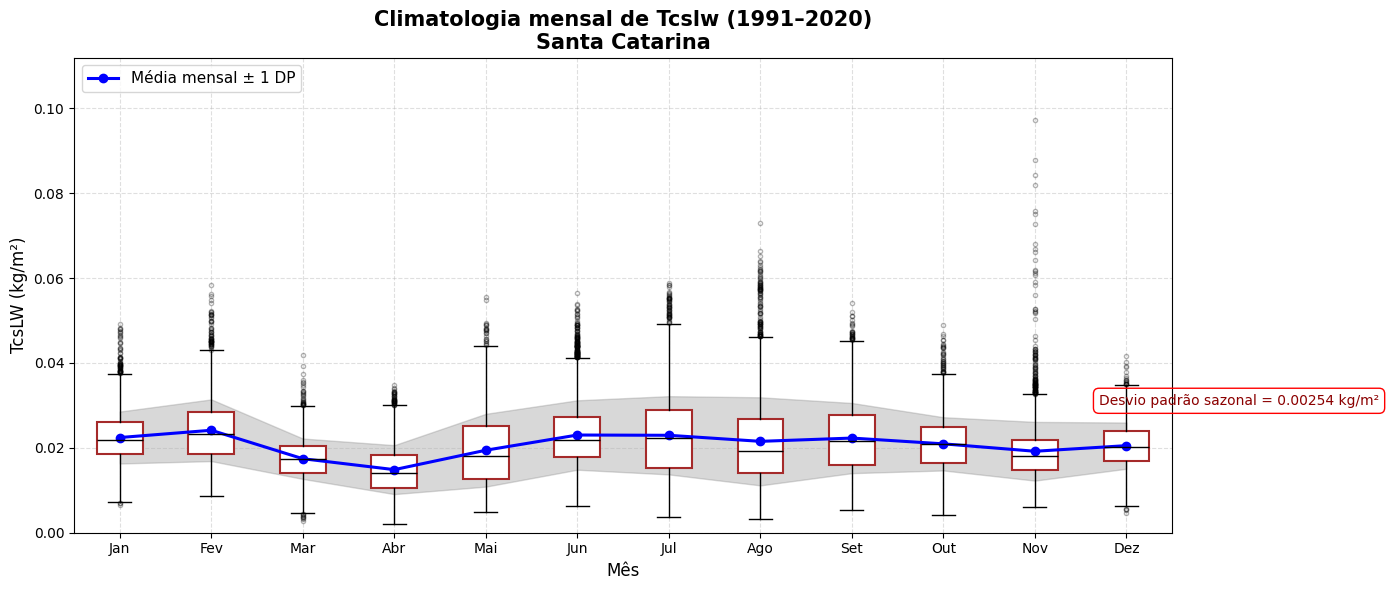

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados de exemplo (valores_mensais, medias e stds já calculados)
dp_sazonal = np.std(medias)
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(14, 6))

# Boxplot com estilo visual aprimorado
ax.boxplot(valores_mensais,
           labels=meses,
           patch_artist=True,
           boxprops=dict(facecolor='white', edgecolor='brown', linewidth=1.5),
           medianprops=dict(color='black', linewidth=1),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', color='gray', markersize=3, alpha=0.3))

# Linha de médias
ax.plot(range(1, 13), medias, color='blue', marker='o', label='Média mensal ± 1 DP', linewidth=2.2)
ax.fill_between(range(1, 13),
                np.array(medias) - np.array(stds),
                np.array(medias) + np.array(stds),
                color='gray', alpha=0.3)

# Título e eixos
ax.set_title('Climatologia mensal de Tcslw (1991–2020)\nSanta Catarina', fontsize=15, weight='bold')
ax.set_ylabel('TcsLW (kg/m²)', fontsize=12)
ax.set_xlabel('Mês', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

# Texto do desvio padrão sazonal
ax.text(11.7, max(medias) + 0.006,
        f'Desvio padrão sazonal = {dp_sazonal:.5f} kg/m²',
        fontsize=10, color='darkred',
        bbox=dict(facecolor='none', edgecolor='red', boxstyle='round,pad=0.4'))

# Limite do eixo y (ajuste se preferir)
ax.set_ylim(0, max([v.max() for v in valores_mensais if len(v) > 0])*1.15)

# Legenda
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()